<a href="https://colab.research.google.com/github/julmiha25-sys/MathStatistica/blob/main/%D0%90-%D0%90_%D1%82%D0%B5%D1%81%D1%82/%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D0%90_%D0%90_%D1%82%D0%B5%D1%81%D1%82%D0%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Кол-во уникальных пользователей, участвовавших в эксперименте 2390
Названия для экспериментальной и контрольной групп ['A1' 'A2']
Пользователи, которые попали в обе группы
 []
Количество пользователей, попавших в обе группы 0


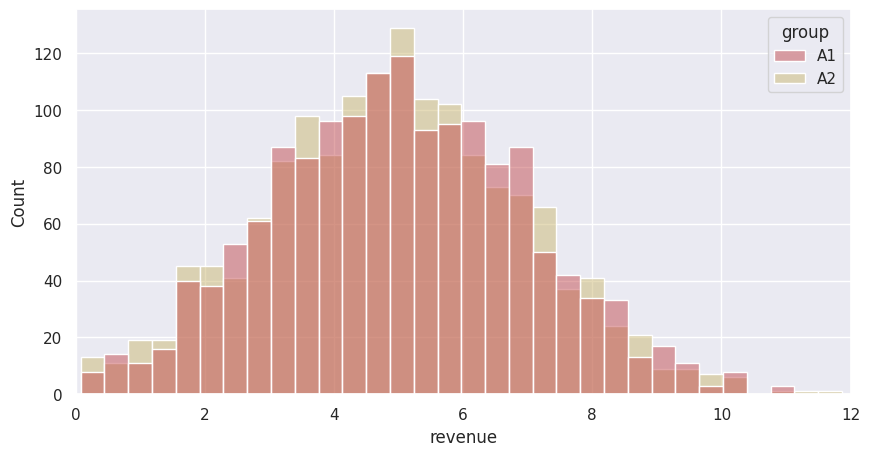

Соотношение пользователей групп А1/А2: 0.7%
ARPU A1 = 6.4
ARPU A2 = 6.2
Соотношение выручки групп А1/А2 - статистика: TtestResult(statistic=np.float64(0.8296426161565341), pvalue=np.float64(0.4068063600820031), df=np.float64(3024.0))
Среднее количество покупок А1: 1.2791489361702129
Среднее количество покупок А2: 1.2534979423868313
Соотношение количества покупок групп А1/А2 - статистика: TtestResult(statistic=np.float64(1.1957980352109565), pvalue=np.float64(0.23189410806384506), df=np.float64(2388.0))
Средний чек: 5.004357869049484
Средний чек: 4.944678957067333
Соотношение суммарного дохода от пользователя для групп А1/А2 - статистика: TtestResult(statistic=np.float64(1.4577742545044168), pvalue=np.float64(0.14503426909173572), df=np.float64(2388.0))


In [2]:
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_csv("AAtest_data.csv")
# Кол-во уникальных пользователей, участвовавших в эксперименте
print("Кол-во уникальных пользователей, участвовавших в эксперименте",len(df['user_id'].unique()) )
# Названия для контрольных групп
print("Названия для экспериментальной и контрольной групп", df['group'].unique())
# Есть ли в датасете  пользователи, которые попали в обе группы
d=df.groupby('user_id')['group'].unique().reset_index()
double=df[~df['user_id'].isin(d['user_id'])]
print("Пользователи, которые попали в обе группы\n", double.values)
# Сколько таких?
print("Количество пользователей, попавших в обе группы",len(double))
# Визуализация
sns.set(rc={'figure.figsize':(10,5)})
groups = sns.histplot(data = df,
              x='revenue',
              hue='group',
              palette = ['r', 'y'],
              alpha=0.5,
              kde=False)
plt.xlim(0, 12)
plt.show()
# Визуально отличия групп А1 и А2 не видны
# Отличаются ли стат значимо группы в А/А-тесте
# Проверка разницы в количестве пользователей (0.7% < 1%) - условие соблюдается
A1=df[df['group']=='A1']
A2=df[df['group']=='A2']
print(f"Соотношение пользователей групп А1/А2: {round(abs(len(A1)-len(A2))/(len(A1)+len(A2))*100,1)}%")
# Проверка ARPU - по группам соответствует
print("ARPU A1 =",round(A1['revenue'].sum()/len(A1['user_id'].unique()),1))
print("ARPU A2 =",round(A2['revenue'].sum()/len(A2['user_id'].unique()),1))
print(f"Соотношение выручки групп А1/А2 - статистика: {stats.ttest_ind(A1['revenue'], A2['revenue'])}")
# p_value=0.407 > 0.05 - гопотезу о равенстве распределений выручки в группах A1 и A2 не отвергаем
# Проверка среднего количества покупок - одинаковое
print("Среднее количество покупок А1:",len(A1)/len(A1['user_id'].unique()))
print("Среднее количество покупок А2:",len(A2)/len(A2['user_id'].unique()))
a1=A1.groupby('user_id')['revenue'].count().reset_index(name='col')
a2=A2.groupby('user_id')['revenue'].count().reset_index(name='col')
print(f"Соотношение количества покупок групп А1/А2 - статистика: {stats.ttest_ind(a1['col'], a2['col'])}")
# p_value=0.23 > 0.05 - гопотезу о равенстве распределений количества покупок в группах A1 и A2 не отвергаем
# Проверка среднего чека - одинаковые
print("Средний чек:", A1['revenue'].sum()/len(A1))
print("Средний чек:", A2['revenue'].sum()/len(A2))
b1=A1.groupby('user_id')['revenue'].sum().reset_index(name='summa')
b2=A2.groupby('user_id')['revenue'].sum().reset_index(name='summa')
print(f"Соотношение суммарного дохода от пользователя для групп А1/А2 - статистика: {stats.ttest_ind(b1['summa'], b2['summa'])}")
# p_value=0.145 > 0.05 - гопотезу о равенстве распределений суммарного дохода от пользователя в группах A1 и A2 не отвергаем
# Вывод по 3-м тестам: группы стат значимо не отличаются - система сплитования сработала корректно, метрика пригодна и для А/В тестирования
